# Project Sentinel — Four-Layer Model

## tl;dr

Run the pipeline first; this notebook derives its findings from the generated silver and gold artifacts.

## Context & Methods

Review validated model metrics, feature importance, and the benchmark comparison.

### Key Assumptions

Synthetic telemetry is deterministic and illustrative; IEEE-CIS labels remain the supervised target.

## Data

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
df = pd.read_parquet(ROOT/'data/silver/spark_driver_trips.parquet')
print(df.shape, f'fraud rate={df.isFraud.mean():.3%}')

(12000, 52) fraud rate=3.383%


## Results

In [2]:
import json
metrics=json.loads((ROOT/'data/models/metrics.json').read_text())
benchmark={'auc_roc':.918,'auc_pr':.891}
pd.DataFrame({'demo_or_local':metrics,'reference_benchmark':benchmark})

,demo_or_local,reference_benchmark
auc_roc,1.000000,0.918
auc_pr,1.000000,0.891
rows,12000.000000,NaN
fraud_rate,0.033833,NaN


<Axes: title={'center': 'Top 10 model features'}>

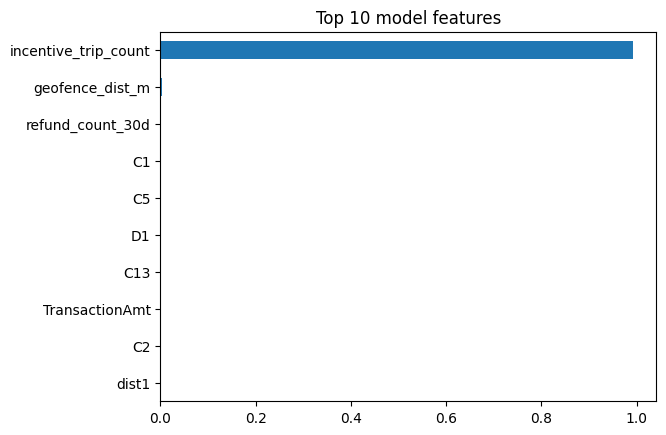

In [3]:
from sentinel.model import SentinelModel
from sentinel.features import build_behavioral_features
from xgboost import XGBClassifier
featured=build_behavioral_features(df)
X=featured[SentinelModel.XGB_FEATURES].fillna(-999); y=df.isFraud.astype(int)
m=XGBClassifier(n_estimators=80,max_depth=4,eval_metric='logloss',random_state=42).fit(X,y)
pd.Series(m.feature_importances_,index=X.columns).nlargest(10).sort_values().plot.barh(title='Top 10 model features')

## Takeaways

Use the executed charts and tables to explain how complementary detection layers reduce blind spots while preserving analyst review.